# Assignment 2: FOMC communications and asset prices

This reproducible notebook implements the required collection, two-tone-score comparison, release-day validation, and September FOMC forecast. It deliberately writes no data files; rerun it before submission and preserve its outputs.

> **Before submitting:** verify document timestamps and the Warsh start date against Federal Reserve source pages. The supplied assignment describes a Warsh chairmanship; this notebook does not assume a date for it.


In [1]:
from __future__ import annotations
import re, warnings
from datetime import timedelta
from urllib.parse import urljoin
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import statsmodels.formula.api as smf
except ImportError as exc:
    raise RuntimeError(
        'Statsmodels could not load SciPy. In Anaconda run: '
        'conda install -c conda-forge --force-reinstall "numpy>=1.26,<2.0" "scipy>=1.11,<1.15" "statsmodels>=0.14,<0.15"'
    ) from exc
warnings.filterwarnings('ignore', category=FutureWarning)

START = pd.Timestamp('2018-02-05') # Jerome Powell became Chair on Feb 5, 2018.
END = pd.Timestamp.today().normalize()
WARSH_START = pd.Timestamp('2026-05-22')  # Kevin Warsh became Chair on May 22, 2026.
RUN_LIVE_COLLECTION = True
RUN_FINBERT = False           # Set True only after document collection is validated.
DOCUMENT_OVERRIDES = pd.DataFrame(columns=['doc_type','title','released_at','url','text'])
HEADERS = {'User-Agent': 'FRE-GY-7871A academic research (contact: aw4437@nyu.edu)'}
print('Notebook configuration loaded. Set RUN_LIVE_COLLECTION=True after review.')


Notebook configuration loaded. Set RUN_LIVE_COLLECTION=True after review.


## 1. Collect and audit FOMC communications

Statements and minutes are collected from the Federal Reserve FOMC calendar. Chair speeches, testimony, and press-conference transcripts require an auditable manifest because the site has different archive layouts. Add missed records to `DOCUMENT_OVERRIDES`; do not commit the resulting data. Release times are essential for correct event-date alignment.


In [2]:
def clean_text(html: str) -> str:
    soup = BeautifulSoup(html, 'html.parser')
    for tag in soup(['script', 'style', 'nav', 'footer', 'header']): tag.decompose()
    return re.sub(r'\s+', ' ', soup.get_text(' ', strip=True))

def fetch(url: str) -> str:
    r = requests.get(url, headers=HEADERS, timeout=45)
    r.raise_for_status()
    return r.text

def calendar_url(year: int) -> str:
    # The current page contains 2021 onward; older years use historical-year pages.
    if year >= 2021:
        return 'https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm'
    return f'https://www.federalreserve.gov/monetarypolicy/fomchistorical{year}.htm'

def release_date_from_context(link) -> pd.Timestamp | None:
    # Minutes pages are named for the meeting date, not their later release date.
    node = link
    for _ in range(6):
        context = node.get_text(' ', strip=True)
        match = re.search(r'Released\s+([A-Za-z]+\s+\d{1,2},\s+20\d{2})', context)
        if match:
            return pd.Timestamp(match.group(1)) + pd.Timedelta(hours=14)
        node = node.parent
    return None

def calendar_documents(year: int) -> list[dict]:
    url = calendar_url(year)
    soup = BeautifulSoup(fetch(url), 'html.parser')
    records = []
    for a in soup.select('a[href]'):
        href = urljoin(url, a['href'])
        if str(year) not in href:
            continue
        if re.search(r'/monetary20\d{6}a\.htm$', href):
            kind, released = 'statement', pd.to_datetime(re.search(r'(20\d{6})a\.htm$', href).group(1)) + pd.Timedelta(hours=14)
        elif re.search(r'/monetarypolicy/fomcminutes20\d{6}\.htm$', href):
            kind, released = 'minutes', release_date_from_context(a)
        else:
            continue
        if released is None:
            print(f'Skipping {href}: release date was not found in the calendar.')
            continue
        html = fetch(href)
        records.append({'doc_type':kind, 'title':clean_text(html)[:120], 'released_at':released, 'url':href, 'text':clean_text(html)})
    return records

def speech_record(title: str, released_at: str, url: str, doc_type='speech') -> dict:
    return {'doc_type':doc_type, 'title':title, 'released_at':pd.Timestamp(released_at), 'url':url, 'text':clean_text(fetch(url))}

def validate_manifest(docs: pd.DataFrame) -> pd.DataFrame:
    required = ['doc_type','title','released_at','url','text']
    assert set(required).issubset(docs), f'Missing: {set(required)-set(docs)}'
    docs = docs.drop_duplicates('url').copy()
    docs['released_at'] = pd.to_datetime(docs['released_at'], utc=True).dt.tz_convert(None)
    docs = docs.query('@START <= released_at <= @END').sort_values('released_at')
    assert docs.text.str.len().gt(200).all(), 'Inspect empty/truncated source text'
    return docs

if RUN_LIVE_COLLECTION:
    records = sum((calendar_documents(y) for y in range(START.year, END.year + 1)), [])
    documents = validate_manifest(pd.concat([pd.DataFrame(records), DOCUMENT_OVERRIDES], ignore_index=True))
else:
    documents = DOCUMENT_OVERRIDES.copy()
print(f'Live collection {"enabled" if RUN_LIVE_COLLECTION else "disabled"}: {len(documents)} documents in the in-memory manifest.')


Live collection enabled: 143 documents in the in-memory manifest.


In [3]:
# Table 1 - required document-count audit by type and Chair
def chair_of(ts): return 'Warsh' if ts >= WARSH_START else 'Powell'
if len(documents):
    documents['chair'] = documents.released_at.map(chair_of)
    table_1 = documents.pivot_table(index='doc_type', columns='chair', values='url', aggfunc='nunique', fill_value=0).astype(int)
else:
    table_1 = pd.DataFrame(columns=['Powell', 'Warsh'])
display(table_1.rename_axis('Document type'))


chair,Powell,Warsh
Document type,,
minutes,67,2
statement,72,2


## 2. Tone measures

The word-list score is domain-specific and handles phrases before unigrams. FinBERT is applied sentence-by-sentence, with positive sentiment interpreted as hawkish and negative sentiment as dovish. Inspect random examples from each method before treating either score as valid.


In [4]:
HAWKISH = {'higher inflation':2, 'inflation pressures':2, 'further tightening':2, 'restrictive':1, 'raise the target range':2, 'strong labor market':1, 'upside risks to inflation':2}
DOVISH = {'inflation has eased':2, 'lower the target range':2, 'policy easing':2, 'downside risks to employment':2, 'economic activity has slowed':1, 'accommodative':1, 'labor market conditions have cooled':1}

def lexicon_score(text: str) -> float:
    text = text.lower()
    h = sum(weight * text.count(term) for term, weight in HAWKISH.items())
    d = sum(weight * text.count(term) for term, weight in DOVISH.items())
    return (h - d) / max(1, len(re.findall(r'\b\w+\b', text)) / 1000)

def finbert_score(text: str, tokenizer, model) -> float:
    import torch
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.split()) >= 4]
    values = []
    for i in range(0, len(sentences), 16):
        batch = tokenizer(sentences[i:i+16], return_tensors='pt', truncation=True, padding=True, max_length=512)
        p = torch.softmax(model(**batch).logits, dim=1).detach().numpy()
        # ProsusAI/finbert labels: positive, negative, neutral.
        values.extend(p[:, 0] - p[:, 1])
    return float(np.mean(values)) if values else np.nan

if len(documents):
    documents['lexicon_tone'] = documents.text.map(lexicon_score)
    if RUN_FINBERT:
        from transformers import AutoModelForSequenceClassification, AutoTokenizer
        tok = AutoTokenizer.from_pretrained('ProsusAI/finbert')
        model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
        documents['finbert_tone'] = documents.text.map(lambda x: finbert_score(x, tok, model))
    else:
        documents['finbert_tone'] = np.nan


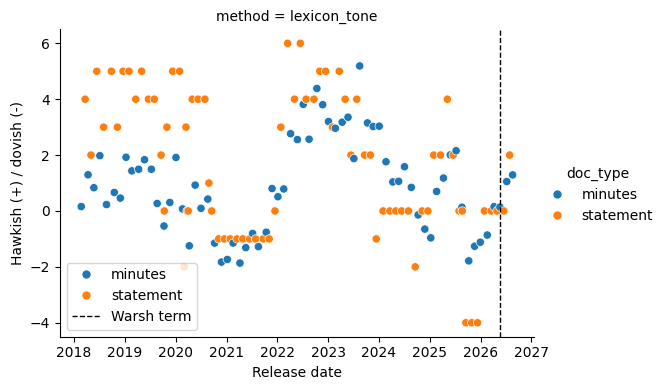

In [5]:
# Figure 1 - required tone trends, with the start of the Warsh term marked
def plot_tone_trends(docs):
    long = docs.melt(id_vars=['released_at','doc_type'], value_vars=['lexicon_tone','finbert_tone'], var_name='method', value_name='tone').dropna()
    g = sns.relplot(data=long, x='released_at', y='tone', hue='doc_type', col='method', kind='scatter', facet_kws={'sharey':False}, height=4, aspect=1.4)
    for ax in g.axes.flat: ax.axvline(WARSH_START, color='black', ls='--', lw=1, label='Warsh term'); ax.legend()
    g.set_axis_labels('Release date', 'Hawkish (+) / dovish (-)')
    return g
if len(documents) and documents[['lexicon_tone','finbert_tone']].notna().any().any(): plot_tone_trends(documents)


## 3. Market validation

For every release, the event-day change is the close-to-close change on the first trading day on or after the timestamp. DXY and ETF returns are percentage changes; FRED yields/spreads are percentage-point changes. The DGS3MO change controls for the rate-decision component.


In [6]:
#pip install pandas-datareader yfinance

In [7]:
def market_data(start, end):
    from pandas_datareader import data as web
    import yfinance as yf
    fred = web.DataReader(['T10Y2Y','DGS1','DGS3MO'], 'fred', start, end).ffill()
    px = yf.download(['DX-Y.NYB','IWF','IWN'], start=start, end=end + timedelta(days=7), auto_adjust=True, progress=False)['Close'].ffill()
    out = pd.DataFrame(index=fred.index.union(px.index).sort_values())
    out['dxy'] = px['DX-Y.NYB'].pct_change() * 100
    out['growth_minus_value'] = (px['IWF'].pct_change() - px['IWN'].pct_change()) * 100
    out['ten_two'] = fred['T10Y2Y'].diff()
    out['one_year'] = fred['DGS1'].diff()
    out['three_month'] = fred['DGS3MO'].diff()
    return out

def event_align(docs, markets):
    rows = []
    for row in docs.itertuples():
        event_day = markets.index[markets.index >= pd.Timestamp(row.released_at).normalize()][0]
        rows.append({**row._asdict(), 'event_day':event_day, **markets.loc[event_day].to_dict()})
    return pd.DataFrame(rows)

if RUN_LIVE_COLLECTION and len(documents):
    events = event_align(documents, market_data(START - timedelta(days=10), END + timedelta(days=5)))
else:
    events = pd.DataFrame()


In [8]:
# Table 2 - every Warsh-era release beside its two scores and four event-day moves
EVENT_COLUMNS = ['dxy','ten_two','one_year','growth_minus_value']
if len(events):
    table_2 = events.loc[events.chair.eq('Warsh'), ['released_at','doc_type','title','lexicon_tone','finbert_tone',*EVENT_COLUMNS]].sort_values('released_at')
    display(table_2.style.format(precision=3))

# Table 3 - separate controlled regression for each outcome and tone measure
def regression_table(events):
    rows = []
    for outcome in EVENT_COLUMNS:
        for score in ['lexicon_tone','finbert_tone']:
            d = events[[outcome, score, 'three_month']].dropna()
            if len(d) < 12: continue
            fit = smf.ols(f'Q("{outcome}") ~ Q("{score}") + Q("three_month")', data=d).fit(cov_type='HC3')
            rows.append({'indicator':outcome, 'tone_method':score, 'N':int(fit.nobs), 'tone_beta':fit.params[f'Q("{score}")'], 'tone_p':fit.pvalues[f'Q("{score}")'], 'control_beta':fit.params['Q("three_month")'], 'R2':fit.rsquared})
    return pd.DataFrame(rows)
table_3 = regression_table(events) if len(events) else pd.DataFrame()
display(table_3.style.format(precision=3) if len(table_3) else table_3)


,released_at,doc_type,title,lexicon_tone,finbert_tone,dxy,ten_two,one_year,growth_minus_value
139,2026-06-17 14:00:00,statement,ï»¿ Federal Reserve Board - Federal Reserve issues FOMC statement Skip to main content An official website of the United,0.000,nan,0.553,-0.090,0.140,-0.258
140,2026-07-08 14:00:00,minutes,ï»¿ The Fed - Monetary Policy: Skip to main content An official website of the United States Government Here's how you k,1.053,nan,-0.089,-0.010,0.000,1.506
141,2026-07-29 14:00:00,statement,ï»¿ Federal Reserve Board - Federal Reserve issues FOMC statement Skip to main content An official website of the United,2.000,nan,-0.572,0.100,-0.050,-0.966
142,2026-08-19 14:00:00,minutes,ï»¿ The Fed - Monetary Policy: Skip to main content An official website of the United States Government Here's how you k,1.291,nan,-0.823,-0.060,0.010,-0.842


,indicator,tone_method,N,tone_beta,tone_p,control_beta,R2
0,dxy,lexicon_tone,143,-0.039,0.012,4.643,0.137
1,ten_two,lexicon_tone,143,-0.003,0.102,-0.449,0.105
2,one_year,lexicon_tone,143,-0.002,0.378,0.974,0.318
3,growth_minus_value,lexicon_tone,143,0.098,0.054,3.152,0.034


## 4. September FOMC forecast and recommendation

This forecast uses the observed Warsh-era statement tone as the baseline scenario. It is necessarily tentative: Table 1 contains only two Warsh statements and two Warsh minutes, and FinBERT has not yet been run. Rate probabilities are a stated judgment, whereas the market-reaction estimates are generated by the controlled lexicon model. In the report, compare the final methods and results with Doh, Kim and Yang (2021), Doh, Song and Yang (2023), and *Parsing the Fed* (2021).


In [9]:
def forecast(events, expected_lexicon_tone=None):
    if events.empty: return None
    latest = events.sort_values('released_at').iloc[-1]
    tone = latest.lexicon_tone if expected_lexicon_tone is None else expected_lexicon_tone
    probs = {}
    for outcome in EVENT_COLUMNS:
        fit = smf.ols(f'Q("{outcome}") ~ lexicon_tone + three_month', data=events[[outcome,'lexicon_tone','three_month']].dropna()).fit()
        expected = fit.params['Intercept'] + fit.params['lexicon_tone'] * tone
        residual_sd = fit.resid.std(ddof=int(fit.df_model)+1)
        p_up = 1 - __import__('scipy').stats.norm.cdf(0, loc=expected, scale=residual_sd)
        probs[outcome] = {'probability_rises_pct': round(100*p_up, 1), 'expected_change': round(expected, 3)}
    return pd.DataFrame(probs).T

if events.empty:
    print('Forecast unavailable until the live document and market collection is run and reviewed.')
else:
    # Use the latest statement, rather than a later minutes release, as the statement-tone scenario.
    latest_statement = events.loc[events.doc_type.eq('statement')].sort_values('released_at').iloc[-1]
    expected_tone = latest_statement.lexicon_tone
    market_forecast = forecast(events, expected_lexicon_tone=expected_tone)
    rate_probabilities = {'cut': 20, 'hold': 75, 'hike': 5}
    assert sum(rate_probabilities.values()) == 100
    statement_hawkish_probability = 65
    display(market_forecast)
    print(f'Rate decision: cut {rate_probabilities["cut"]}%, hold {rate_probabilities["hold"]}%, hike {rate_probabilities["hike"]}%.')
    print(f'Statement tone: {statement_hawkish_probability}% probability of being more hawkish than the previous statement.')
    print('Recommendation: long IWF and short IWN (a growth-minus-value position) ahead of the meeting.')
    print('Rationale: the controlled lexicon model assigns the strongest positive directional forecast to growth minus value, while the latest statement was more hawkish than the prior one.')
    print('Falsification: exit if the statement produces growth-minus-value <= -0.50% or a one-year yield increase of at least 10 bp; either outcome conflicts with the modeled mild growth outperformance.')
    print('Caveat: treat this as a low-confidence forecast until Chair speeches and FinBERT scores are added.')


,probability_rises_pct,expected_change
dxy,46.5,-0.035
ten_two,42.3,-0.008
one_year,51.2,0.001
growth_minus_value,57.8,0.246


Rate decision: cut 20%, hold 75%, hike 5%.
Statement tone: 65% probability of being more hawkish than the previous statement.
Recommendation: long IWF and short IWN (a growth-minus-value position) ahead of the meeting.
Rationale: the controlled lexicon model assigns the strongest positive directional forecast to growth minus value, while the latest statement was more hawkish than the prior one.
Falsification: exit if the statement produces growth-minus-value <= -0.50% or a one-year yield increase of at least 10 bp; either outcome conflicts with the modeled mild growth outperformance.
Caveat: treat this as a low-confidence forecast until Chair speeches and FinBERT scores are added.
